<a href="https://colab.research.google.com/github/Rozi1/APoT/blob/master/Low_Graduation_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Machine Learning Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# Model Evaluation and Selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, precision_score,
    precision_recall_fscore_support, roc_auc_score, log_loss,
    confusion_matrix, roc_curve, auc
)

# Feature Selection
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif

# Statistical Analysis
import statsmodels.api as sm
from statsmodels.formula.api import ols




# 2. Reading Dataset

In [3]:
# Dataset Link : https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention
data = pd.read_csv("dataset.csv")
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 3. Exploratory Data Analysis

## Dataset Overview

In [4]:
data.shape

(4424, 35)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [6]:
pd.set_option('display.max_columns', None)
data.describe().round(3)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000
mean,1.179,6.887,1.728,9.899,0.891,2.531,1.255,12.322,16.455,7.318,7.819,0.548,0.012,0.114,0.881,0.352,0.248,23.265,0.025,0.710,6.271,8.299,4.707,10.641,0.138,0.542,6.232,8.063,4.436,10.230,0.150,11.566,1.228,0.002
std,0.606,5.299,1.314,4.332,0.312,3.964,1.748,9.026,11.045,3.998,4.857,0.498,0.107,0.317,0.324,0.478,0.432,7.588,0.156,2.361,2.480,4.179,3.094,4.844,0.691,1.919,2.196,3.948,3.015,5.211,0.754,2.664,1.383,2.270
min,1.000,1.000,0.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,17.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7.600,-0.800,-4.060
25%,1.000,1.000,1.000,6.000,1.000,1.000,1.000,2.000,3.000,5.000,5.000,0.000,0.000,0.000,1.000,0.000,0.000,19.000,0.000,0.000,5.000,6.000,3.000,11.000,0.000,0.000,5.000,6.000,2.000,10.750,0.000,9.400,0.300,-1.700
50%,1.000,8.000,1.000,10.000,1.000,1.000,1.000,13.000,14.000,6.000,8.000,1.000,0.000,0.000,1.000,0.000,0.000,20.000,0.000,0.000,6.000,8.000,5.000,12.286,0.000,0.000,6.000,8.000,5.000,12.200,0.000,11.100,1.400,0.320
75%,1.000,12.000,2.000,13.000,1.000,1.000,1.000,22.000,27.000,10.000,10.000,1.000,0.000,0.000,1.000,1.000,0.000,25.000,0.000,0.000,7.000,10.000,6.000,13.400,0.000,0.000,7.000,10.000,6.000,13.333,0.000,13.900,2.600,1.790
max,6.000,18.000,9.000,17.000,1.000,17.000,21.000,29.000,34.000,32.000,46.000,1.000,1.000,1.000,1.000,1.000,1.000,70.000,1.000,20.000,26.000,45.000,26.000,18.875,12.000,19.000,23.000,33.000,20.000,18.571,12.000,16.200,3.700,3.510


In [7]:
# check total null values
data.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


In [8]:
# check if values duplicated
data.duplicated().sum()

0

## Target Distribution

<ipython-input-9-d09a57db1f44>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=["Dropout", "Enrolled", "Graduate"], y=data_pie.values, palette="pastel")


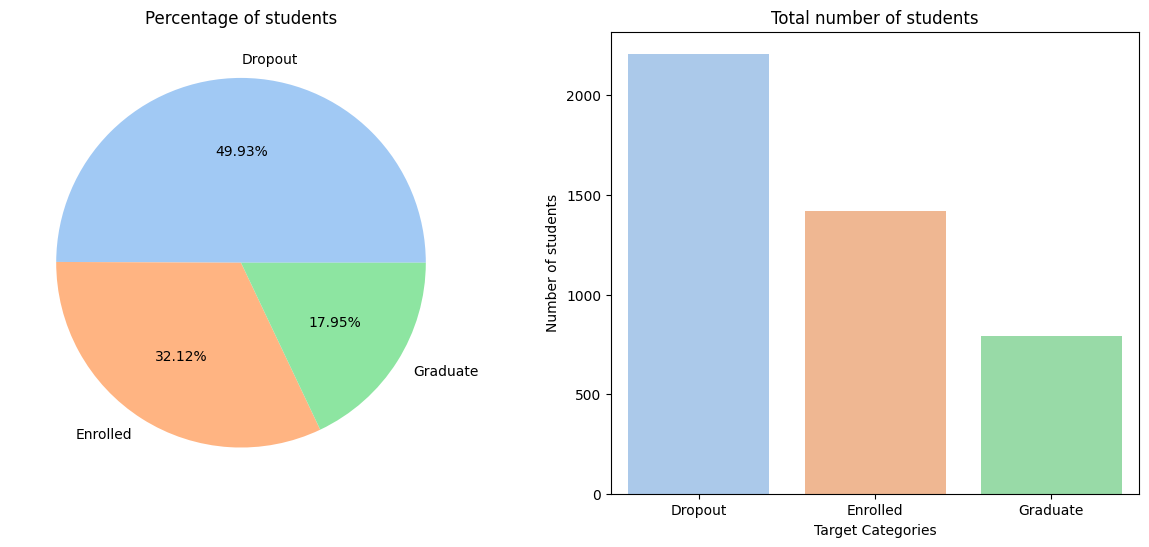

In [9]:
data_pie = data['Target'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.pie(data_pie,  autopct="%.2f%%", labels=["Dropout", "Enrolled", "Graduate"],colors=sns.color_palette('pastel'))
ax1.set_title('Percentage of students')

ax2 = sns.barplot(x=["Dropout", "Enrolled", "Graduate"], y=data_pie.values, palette="pastel")
ax2.set(xlabel='Target Categories', ylabel='Number of students')
ax2.set_title('Total number of students')
#ax2.bar_label(container=ax2.containers[0], labels=data_pie.values, fontsize=10, color='black')

plt.show()

### Gender

<ipython-input-10-ee383ae8bfcc>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=data_gender_labels, y=data_gender.values, palette="pastel")


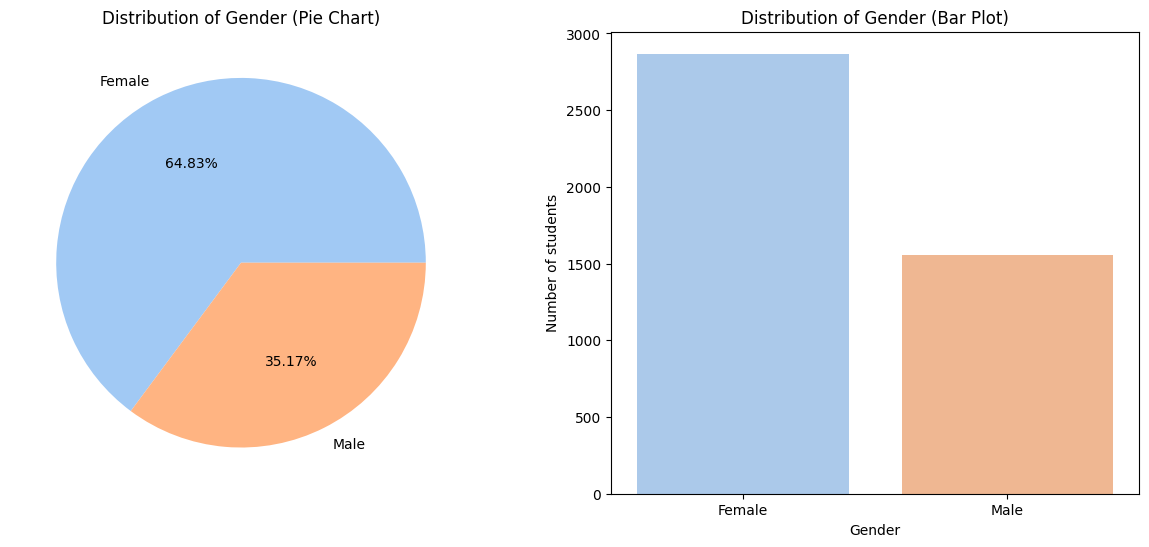

In [10]:
data_gender = data['Gender'].value_counts()

gender_mapping = {0: 'Female', 1: 'Male'}
data_gender_labels = data_gender.index.map(gender_mapping)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.pie(data_gender, labels=data_gender_labels, autopct="%.2f%%", colors=sns.color_palette('pastel'))
ax1.set_title('Distribution of Gender (Pie Chart)')

ax2 = sns.barplot(x=data_gender_labels, y=data_gender.values, palette="pastel")
ax2.set(xlabel='Gender', ylabel='Number of students')
ax2.set_title('Distribution of Gender (Bar Plot)')

#ax2.bar_label(container=ax2.containers[0], labels=data_gender.values, fontsize=10, color='black')
plt.show()

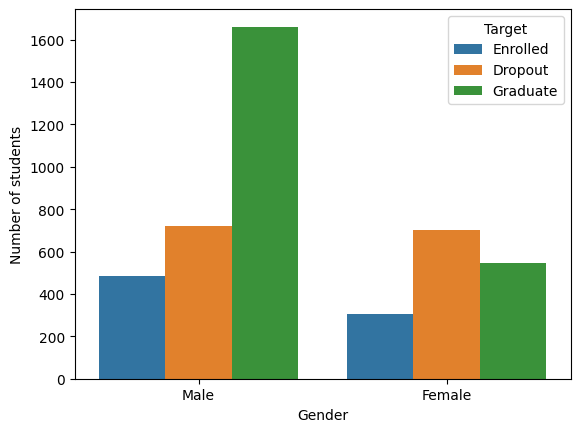

In [11]:
sns.countplot(data=data, x='Gender', hue='Target', order=[0, 1], hue_order=['Enrolled', 'Dropout', 'Graduate'])
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.ylabel('Number of students')
plt.show()

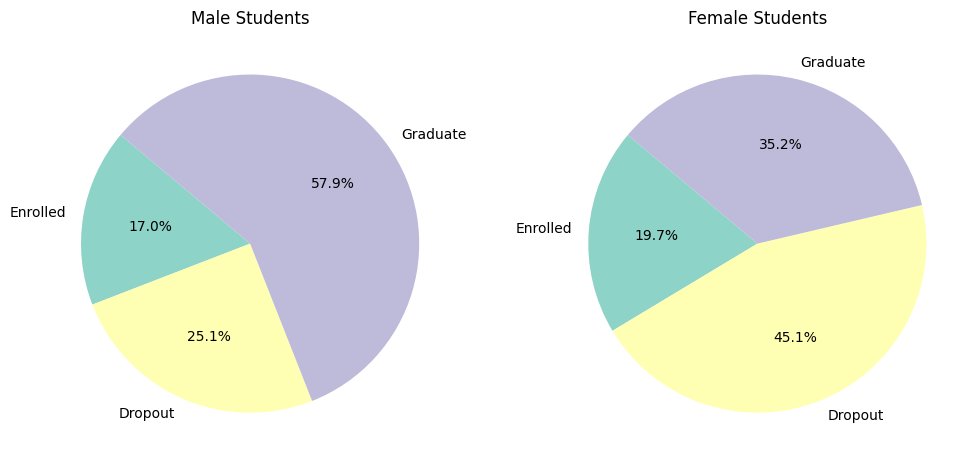

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data by gender and count the number of students in each Target category
male_data = data[data['Gender'] == 0]['Target'].value_counts()
female_data = data[data['Gender'] == 1]['Target'].value_counts()

# Labels for the Target categories
target_labels = ['Enrolled', 'Dropout', 'Graduate']

# Map the counts to the correct order for Target categories
male_counts = male_data.reindex(target_labels).fillna(0)
female_counts = female_data.reindex(target_labels).fillna(0)

# Plot the pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Male students pie chart
axes[0].pie(male_counts, labels=target_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
axes[0].set_title('Male Students')

# Female students pie chart
axes[1].pie(female_counts, labels=target_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
axes[1].set_title('Female Students')

plt.show()


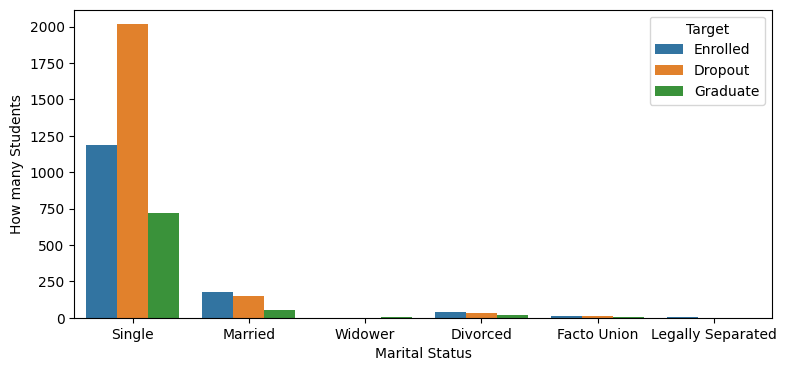

In [13]:
plt.figure(figsize=(9, 4))

sns.countplot(data=data, x='Marital status', hue='Target')

plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=['Single', 'Married', 'Widower', 'Divorced', 'Facto Union', 'Legally Separated'])
plt.xlabel('Marital Status')
plt.ylabel('How many Students')

target_labels = ['Enrolled', 'Dropout', 'Graduate']
plt.legend(title='Target', labels=target_labels)

plt.show()


# 4. Data Preprocessing

In [14]:
data_filtered = data[data['Target'] != 'Enrolled']
data_filtered.shape

(3630, 35)

<ipython-input-15-10929023e25b>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=labels, y=counts, palette="pastel")


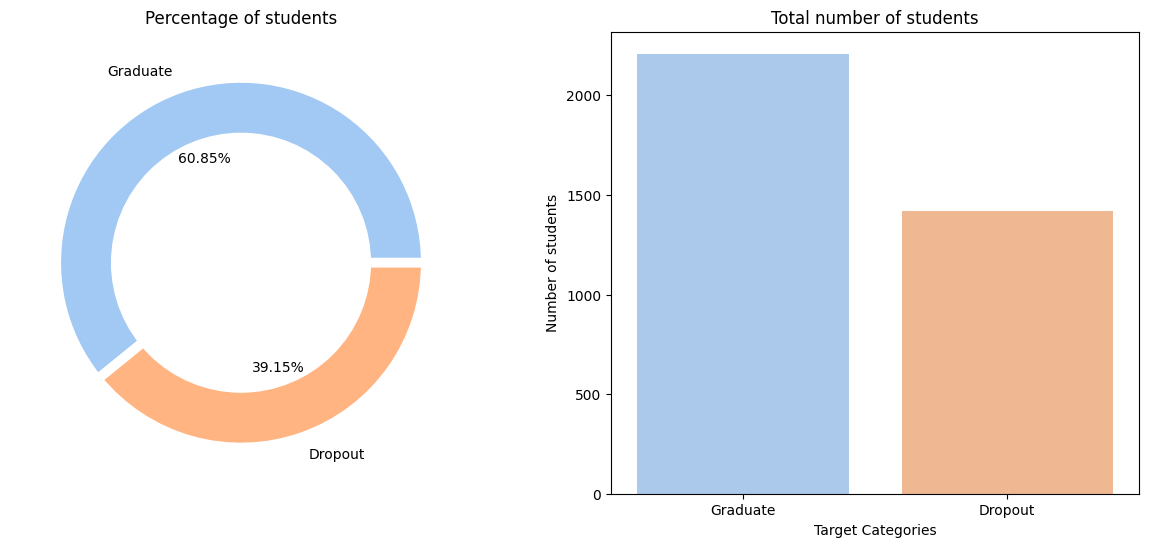

In [15]:
data_counts = data_filtered['Target'].value_counts()

labels = data_counts.index
counts = data_counts.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

circle = plt.Circle((0, 0), 0.7, color='white')
ax1.pie(counts, labels=labels, autopct="%.2f%%", colors=sns.color_palette('pastel'), wedgeprops={'linewidth': 7, 'edgecolor': 'white'})
ax1.set_title('Percentage of students')
ax1.add_artist(circle)

ax2 = sns.barplot(x=labels, y=counts, palette="pastel")
ax2.set(xlabel='Target Categories', ylabel='Number of students')
ax2.set_title('Total number of students')
#ax2.bar_label(container=ax2.containers[0], labels=counts, fontsize=10, color='black')

plt.show()

In [16]:
data_no_outliers = data_filtered.copy()

data_no_outliers['Target'] = data_no_outliers['Target'].map({
    'Dropout': 0,
    'Graduate': 1
})

In [17]:
data_no_outliers.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1


In [18]:
data_no_outliers.shape

(3630, 35)

## Heatmap Correlation

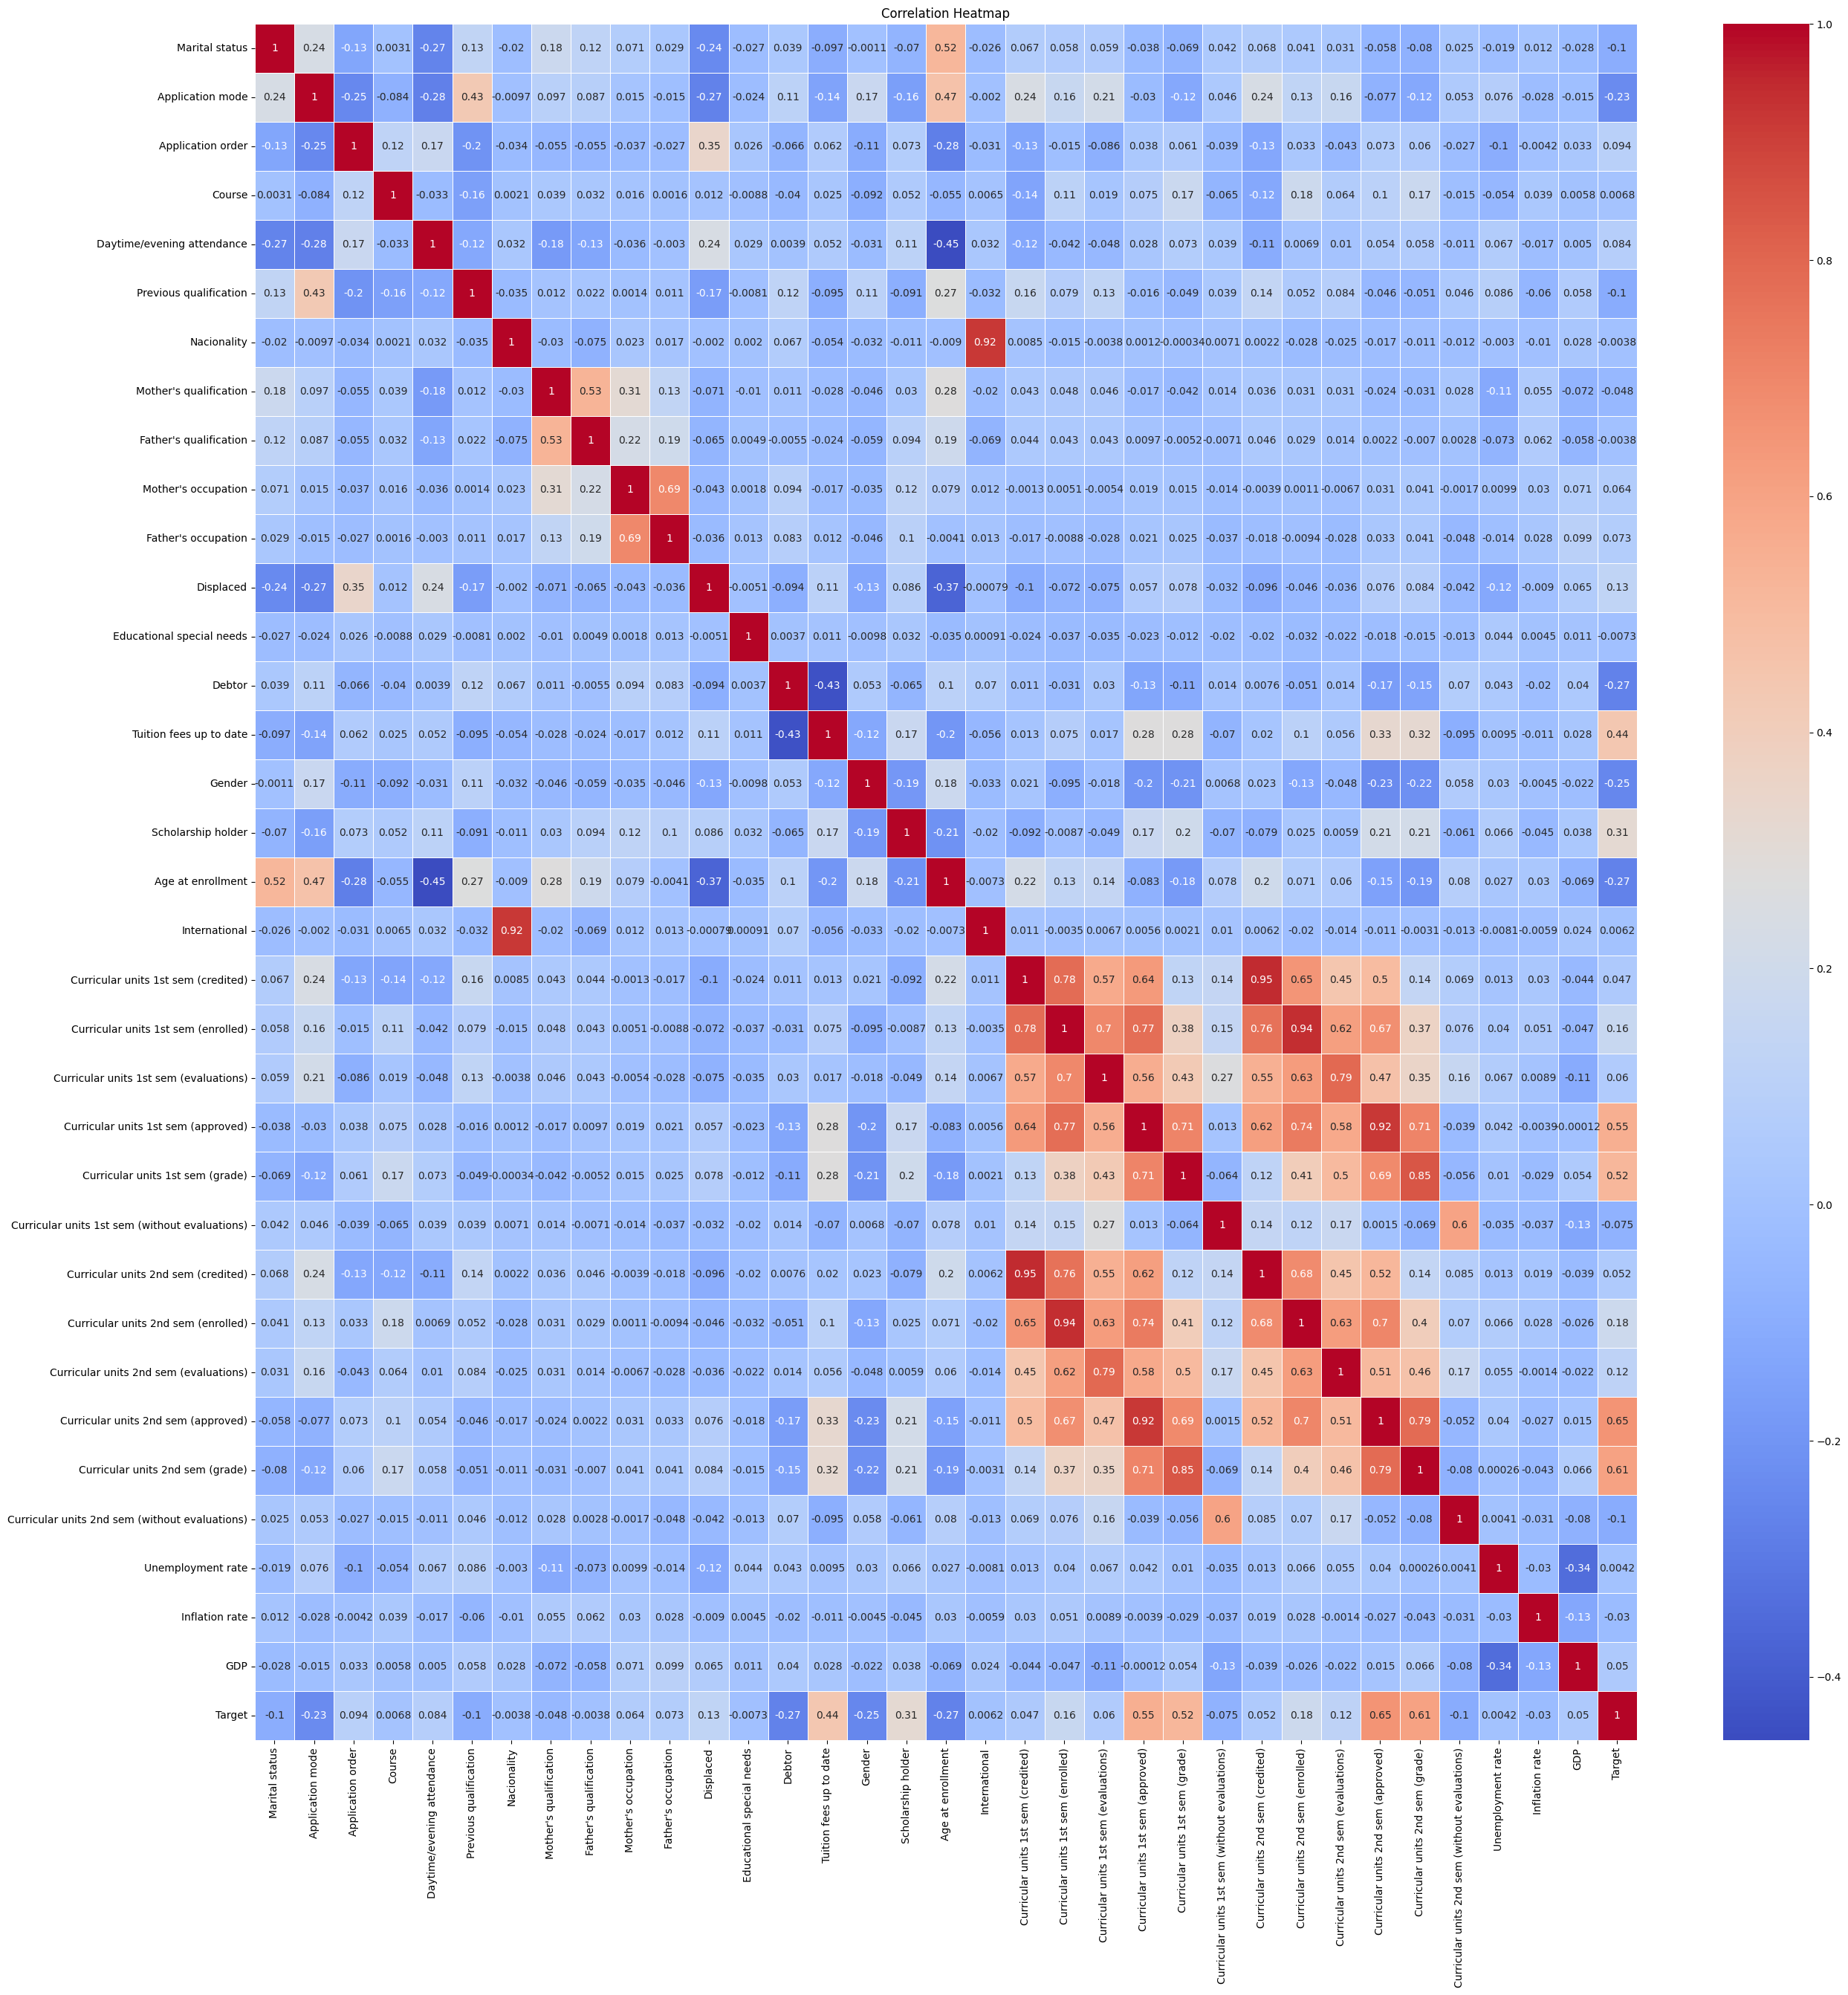

In [19]:
plt.figure(figsize=(30, 30))
sns.heatmap(data_no_outliers.corr() , annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

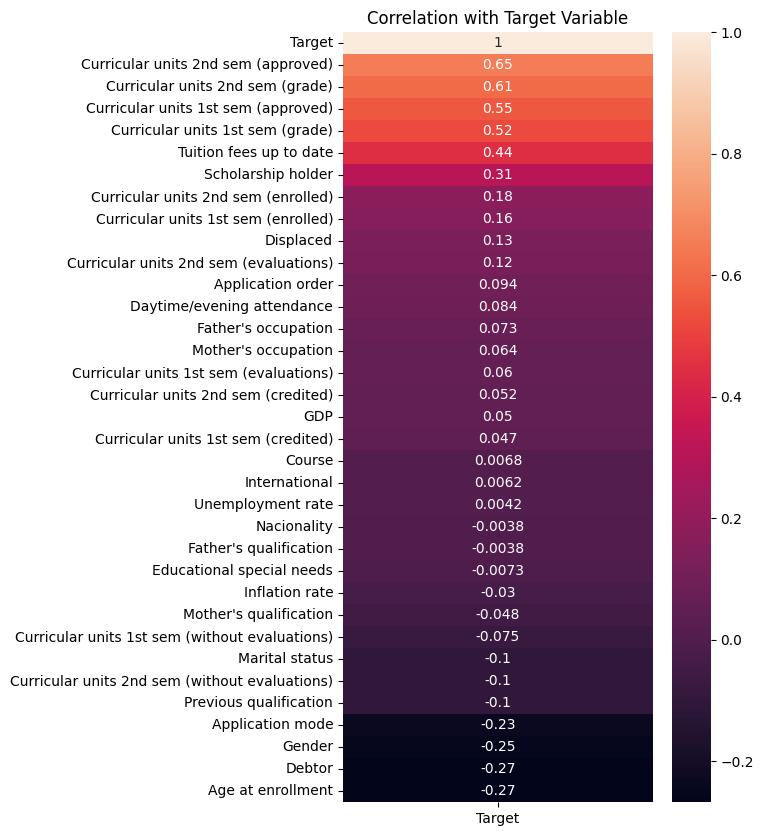

In [20]:
data_2 = data_no_outliers.copy()

data_2.replace("Dropout",0,inplace=True)
data_2.replace("Enrolled",1,inplace=True)
data_2.replace("Graduate",2,inplace=True)


plt.figure(figsize = (5,10))
sns.heatmap(data_2.corr()[['Target']].sort_values(by='Target', ascending=False), annot = True)
plt.title('Correlation with Target Variable')
plt.show()

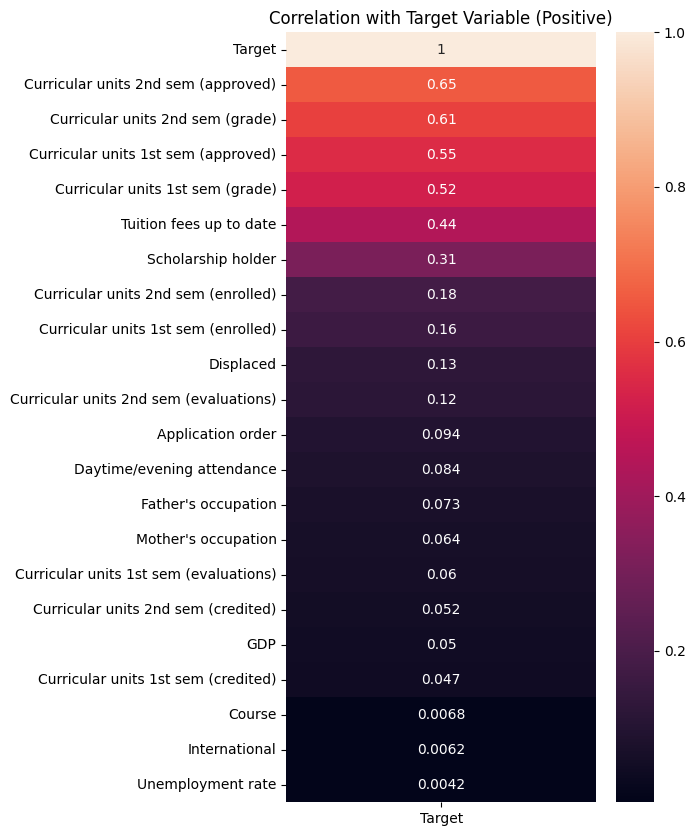

In [21]:
correlation_matrix = data_2.corr()

positive_correlation_features = correlation_matrix['Target'][correlation_matrix['Target'] > 0].index

data_no_outliers = data_2[positive_correlation_features]

plt.figure(figsize=(5, 10))
sns.heatmap(data_no_outliers.corr()[['Target']].sort_values(by='Target', ascending=False), annot=True)
plt.title('Correlation with Target Variable (Positive)')
plt.show()

In [22]:
data_no_outliers.shape

(3630, 22)

## Box Plot

<ipython-input-23-06e22af6dea0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=data_no_outliers, palette='viridis')
<ipython-input-23-06e22af6dea0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=data_no_outliers, palette='viridis')
<ipython-input-23-06e22af6dea0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=data_no_outliers, palette='viridis')
<ipython-input-23-06e22af6dea0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

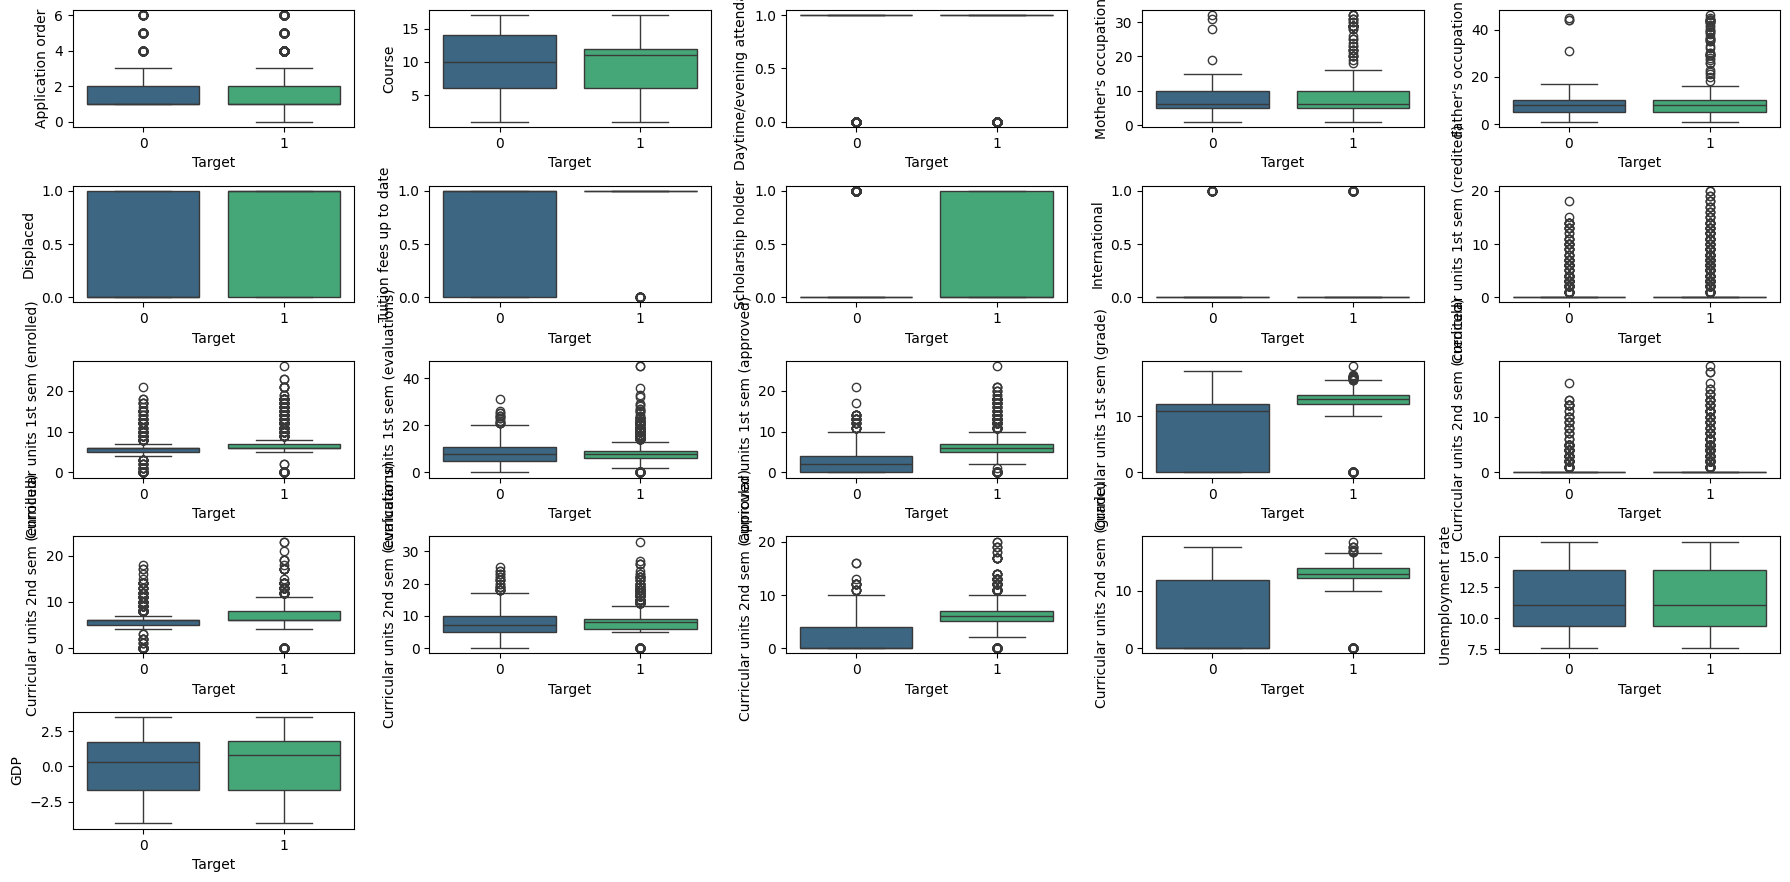

In [23]:
plt.figure(figsize=(18, 12))
gs = GridSpec(7, 5)

for i, col in enumerate(data_no_outliers.columns[:-1]):
    ax = plt.subplot(gs[i])
    sns.boxplot(x='Target', y=col, data=data_no_outliers, palette='viridis')
    ax.set_xlabel('Target', fontsize=10)
    ax.set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()


<ipython-input-24-99a54cdb2e49>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=data_no_outliers, palette='viridis')
<ipython-input-24-99a54cdb2e49>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=data_no_outliers, palette='viridis')
<ipython-input-24-99a54cdb2e49>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=data_no_outliers, palette='viridis')
<ipython-input-24-99a54cdb2e49>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

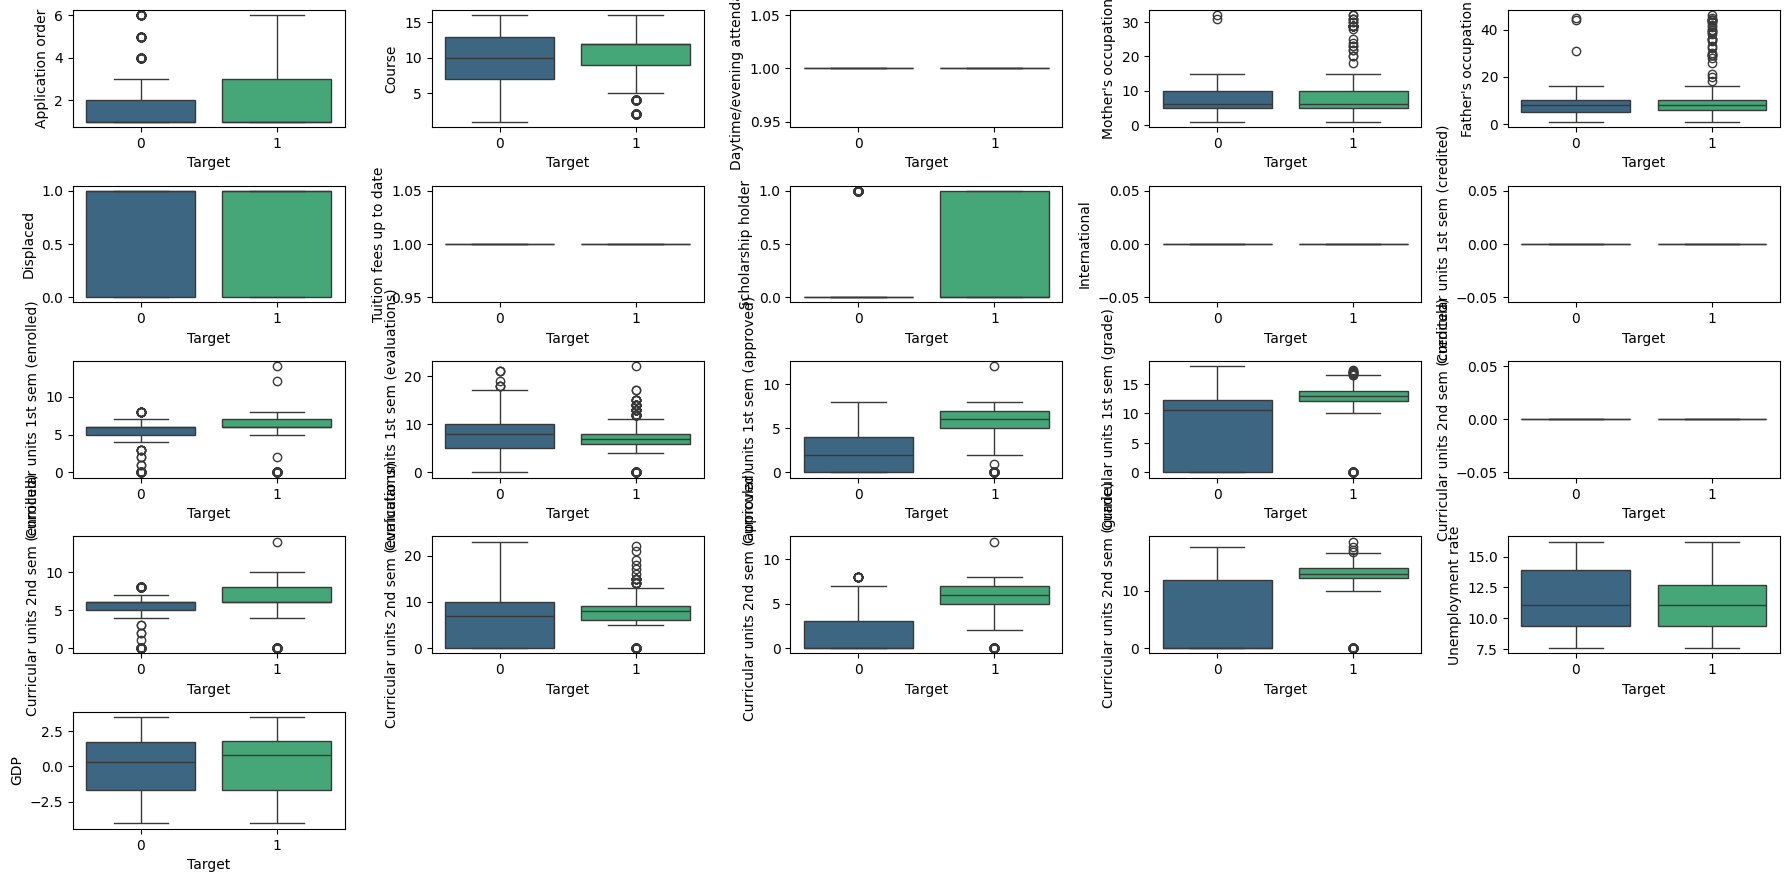

In [24]:
def remove_outliers_iqr(df, column, k):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

for col in data_no_outliers.columns[:-1]:
    data_no_outliers = remove_outliers_iqr(data_no_outliers, col, 10)

plt.figure(figsize=(18, 12))
gs = GridSpec(7, 5)

for i, col in enumerate(data_no_outliers.columns[:-1]):
    ax = plt.subplot(gs[i])
    sns.boxplot(x='Target', y=col, data=data_no_outliers, palette='viridis')
    ax.set_xlabel('Target', fontsize=10)
    ax.set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

In [25]:
data.shape

(4424, 35)

In [26]:
data_no_outliers.shape

(2437, 22)

# 5. Model Selection and Training

In [27]:
X = data_no_outliers.drop('Target', axis=1)
y = data_no_outliers['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

Names=list(X_train.columns.values)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
print("X_train : ",X_train.shape)
print("X_test : ",X_test.shape)
print("y_train : ",y_train.shape)
print("y_test : ",y_test.shape)

X_train :  (1632, 21)
X_test :  (805, 21)
y_train :  (1632,)
y_test :  (805,)


In [29]:
print("\nCounts of targets in y_train:")
print("Target 0:", sum(y_train == 0))
print("Target 1:", sum(y_train == 1))


Counts of targets in y_train:
Target 0: 477
Target 1: 1155


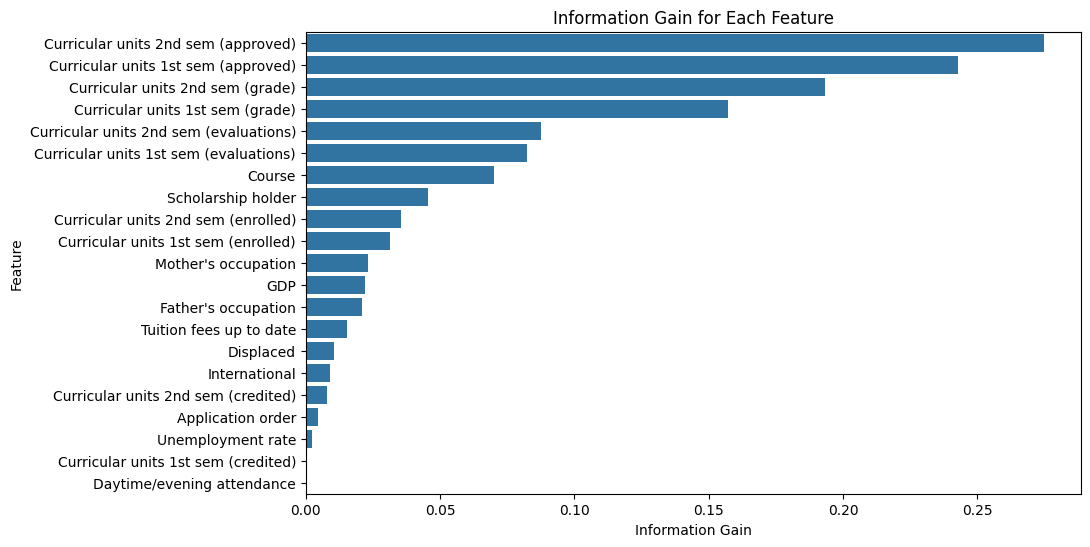

In [30]:
# Calculate Information Gain (mutual information)
info_gain = mutual_info_classif(X_train, y_train)

# Create a DataFrame to visualize
info_gain_df = pd.DataFrame({'Feature': X.columns, 'Information Gain': info_gain})

# Sort by Information Gain
info_gain_df = info_gain_df.sort_values(by='Information Gain', ascending=False)

# Plot the Information Gain
plt.figure(figsize=(10, 6))
sns.barplot(x='Information Gain', y='Feature', data=info_gain_df)
plt.title('Information Gain for Each Feature')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:278: UserWarning: Feature 2 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:278: UserWarning: Feature 6 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:278: UserWarning: Feature 8 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:278: UserWarning: Feature 9 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.10/

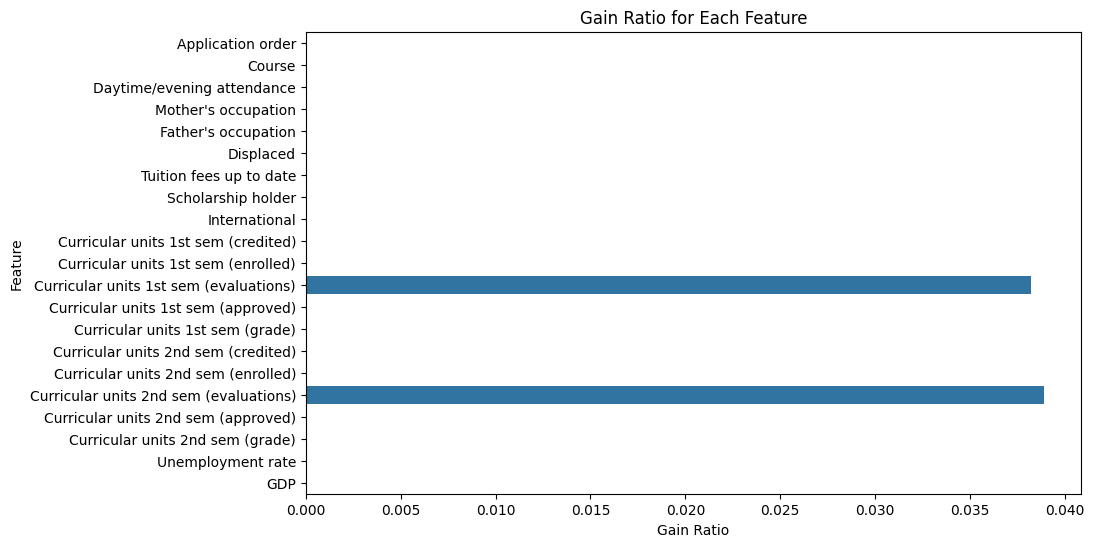

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import mutual_info_classif

# Function to calculate entropy
def entropy(labels):
    probs = np.bincount(labels) / len(labels)
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

# Function to calculate gain ratio
def gain_ratio(X, y, bins=10):
    # Discretize features into bins (to calculate probabilities)
    discretizer = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='uniform')
    X_binned = discretizer.fit_transform(X)

    # Convert to integers
    X_binned = X_binned.astype(int)

    # Calculate Information Gain (Mutual Information)
    info_gain = mutual_info_classif(X_binned, y)

    # Calculate Intrinsic Value (H(X)) for Gain Ratio
    intrinsic_value = np.apply_along_axis(lambda x: -np.sum(np.bincount(x) / len(x) * np.log2(np.bincount(x) / len(x))), axis=0, arr=X_binned)

    # Gain Ratio Calculation
    gain_ratio = info_gain / intrinsic_value

    return gain_ratio

# Applying the custom gain_ratio function
gain_ratio_values = gain_ratio(X_train, y_train)

# Assuming feature names are known from the original DataFrame
feature_names = data_no_outliers.drop('Target', axis=1).columns

# Creating a DataFrame for better visualization
gain_ratio_df = pd.DataFrame({'Feature': feature_names, 'Gain Ratio': gain_ratio_values})

# Plot the Gain Ratio
plt.figure(figsize=(10, 6))
sns.barplot(x='Gain Ratio', y='Feature', data=gain_ratio_df)
plt.title('Gain Ratio for Each Feature')
plt.show()



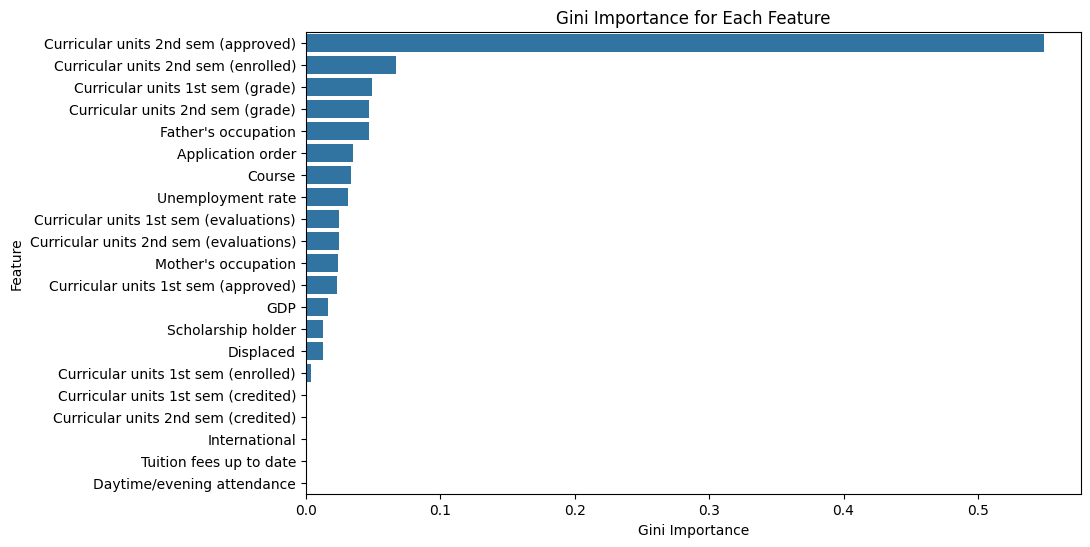

In [32]:
# Train a decision tree classifier
clf = DecisionTreeClassifier(criterion='gini')
clf.fit(X_train, y_train)

# Extract feature importance (Gini Index)
gini_importance = clf.feature_importances_

# Create a DataFrame for Gini Index
gini_df = pd.DataFrame({'Feature': X.columns, 'Gini Importance': gini_importance})

# Sort by Gini Importance
gini_df = gini_df.sort_values(by='Gini Importance', ascending=False)

# Plot the Gini Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Gini Importance', y='Feature', data=gini_df)
plt.title('Gini Importance for Each Feature')
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [ 2  6  8  9 14] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


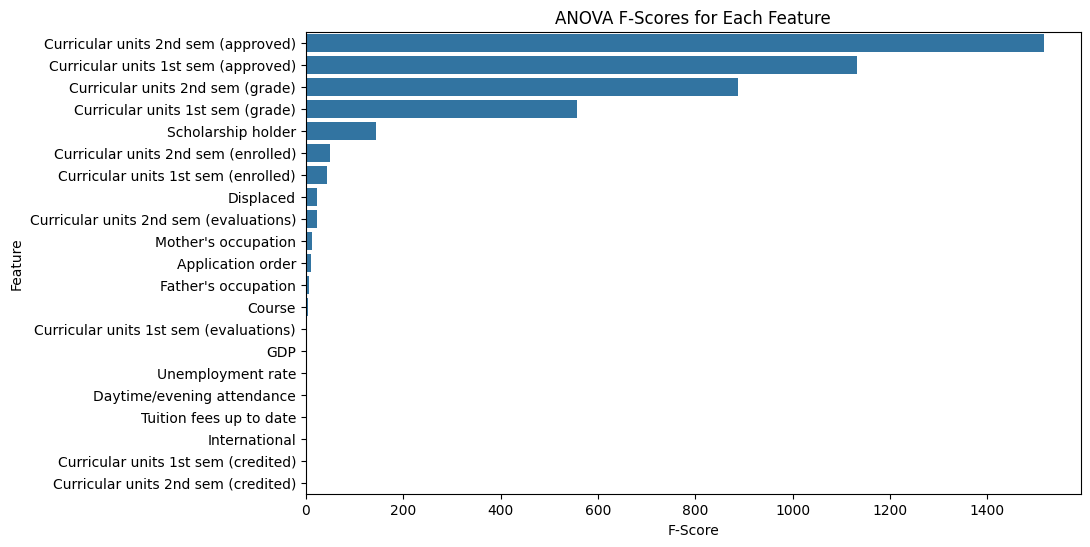

In [33]:
# Apply ANOVA (F-Test)
anova_selector = SelectKBest(f_classif, k='all')
anova_selector.fit(X_train, y_train)

# Get the F-scores and p-values
f_scores = anova_selector.scores_
p_values = anova_selector.pvalues_

# Create a DataFrame for ANOVA
anova_df = pd.DataFrame({'Feature': X.columns, 'F-Score': f_scores, 'p-value': p_values})

# Sort by F-Score
anova_df = anova_df.sort_values(by='F-Score', ascending=False)

# Plot the F-Scores
plt.figure(figsize=(10, 6))
sns.barplot(x='F-Score', y='Feature', data=anova_df)
plt.title('ANOVA F-Scores for Each Feature')
plt.show()


In [34]:
algorithms = ['K-Nearest Neighbors', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'Naive Bayes']
accuracies = []
precisions = []
recalls = []
f1_scores = []


def append_metrics(accuracy, precision, recall, f1):
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

## 1-  K-Nearest Neighbors

Best Parameters: {'n_neighbors': 13}
Accuracy: 0.88
Precision: 0.89
Recall: 0.88
F1-score: 0.87


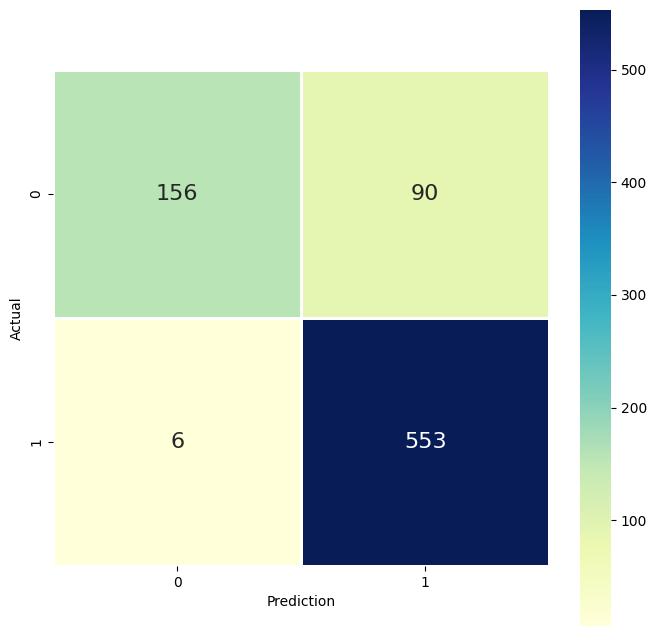

In [35]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 30]
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


best_params = grid_search.best_params_
print("Best Parameters:", best_params)


best_knn = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'])
best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

append_metrics(accuracy, precision, recall, f1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, fmt=".0f", cmap="YlGnBu", linewidth=1, square=True, annot=True, annot_kws={"fontsize": 16}, ax=ax)
ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
plt.show()


## 2- Logistic Regression


Best Parameters for Logistic Regression: {'C': 1}

Logistic Regression with Hyperparameter Tuning:
Accuracy: 0.90
Precision: 0.90
Recall: 0.90
F1-score: 0.90


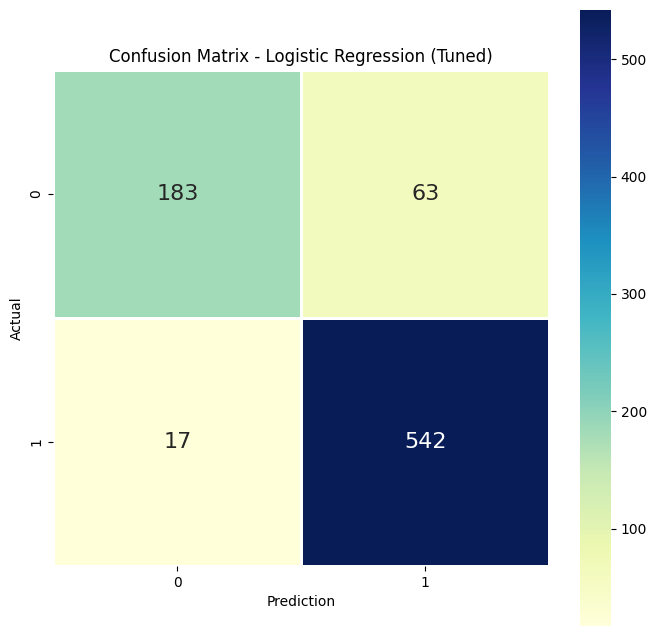

In [36]:

param_grid_logistic = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_logistic = GridSearchCV(LogisticRegression(random_state=42), param_grid_logistic, cv=5, scoring='accuracy')
grid_search_logistic.fit(X_train, y_train)

best_params_logistic = grid_search_logistic.best_params_

print("\nBest Parameters for Logistic Regression:", best_params_logistic)

best_logistic_model = LogisticRegression(C=best_params_logistic['C'], random_state=42)
best_logistic_model.fit(X_train, y_train)

y_pred_logistic_tuned = best_logistic_model.predict(X_test)

accuracy_logistic_tuned = accuracy_score(y_test, y_pred_logistic_tuned)
precision_logistic_tuned, recall_logistic_tuned, f1_logistic_tuned, _ = precision_recall_fscore_support(y_test, y_pred_logistic_tuned, average='weighted')

print("\nLogistic Regression with Hyperparameter Tuning:")
print(f"Accuracy: {accuracy_logistic_tuned:.2f}")
print(f"Precision: {precision_logistic_tuned:.2f}")
print(f"Recall: {recall_logistic_tuned:.2f}")
print(f"F1-score: {f1_logistic_tuned:.2f}")

append_metrics(accuracy_logistic_tuned, precision_logistic_tuned, recall_logistic_tuned, f1_logistic_tuned)

cm_logistic_tuned = confusion_matrix(y_test, y_pred_logistic_tuned)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm_logistic_tuned, fmt=".0f", cmap="YlGnBu", linewidth=1, square=True, annot=True, annot_kws={"fontsize": 16}, ax=ax)
ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Tuned)")
plt.show()

## 3- Decision Tree

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=auto;, score=nan total time=   0.0s
[CV 2/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=auto;, score=nan total time=   0.0s
[CV 3/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=auto;, score=nan total time=   0.0s
[CV 4/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=auto;, score=nan total time=   0.0s
[CV 5/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=auto;, score=nan total time=   0.0s
[CV 1/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=sqrt;, score=0.813 total time=   0.0s
[CV 2/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=sqrt;, score=0.844 total time=   0.0s
[CV 3/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=sqrt;, score=0.850 total time=   0.0s
[CV 4/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=sqrt;, score=0

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/util

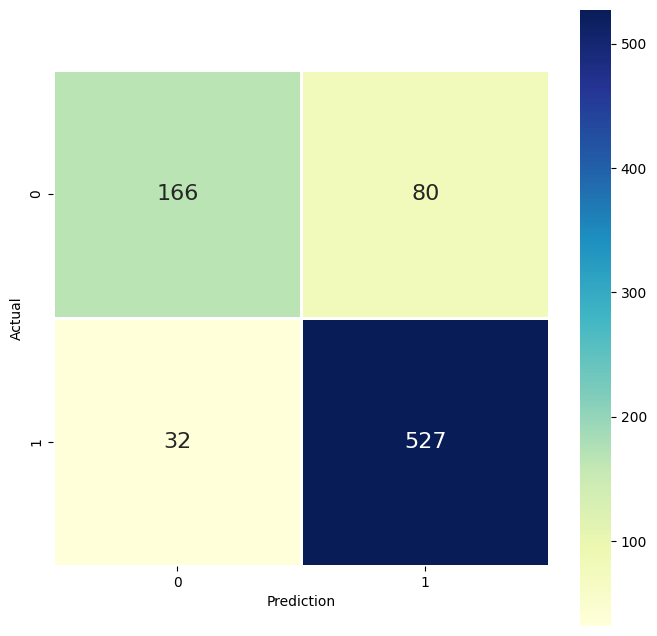

In [37]:
tree_clas = DecisionTreeClassifier(random_state=1024)

param_grid = {'max_features': ['auto', 'sqrt', 'log2'],
              'ccp_alpha': [0.1, .01, .001],
              'max_depth' : [5, 6, 7, 8, 9],
              'criterion' :['gini', 'entropy']
             }


grid_search = GridSearchCV(tree_clas, param_grid, cv=5, scoring='accuracy', refit = True, verbose = 3)
grid_search.fit(X_train, y_train)

best_params_tree_clas = grid_search.best_params_
print("Best Parameters:", best_params_tree_clas)

best_tree_clas = DecisionTreeClassifier(max_features=best_params_tree_clas['max_features'], ccp_alpha=best_params_tree_clas['ccp_alpha'], max_depth=best_params_tree_clas['max_depth'], criterion=best_params_tree_clas['criterion'] )
best_tree_clas.fit(X_train, y_train)

y_pred = best_tree_clas.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

append_metrics(accuracy, precision, recall, f1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, fmt=".0f", cmap="YlGnBu", linewidth=1, square=True, annot=True, annot_kws={"fontsize": 16}, ax=ax)

ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
plt.show()

## 4- Random Forest

Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Accuracy: 0.91
Precision: 0.91
Recall: 0.91
F1-score: 0.90


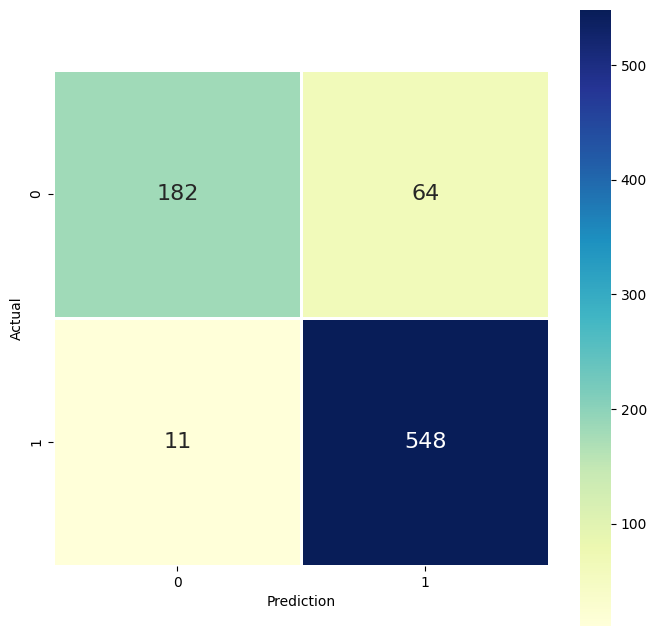

In [38]:
rf = RandomForestClassifier()
param_grid = {'n_estimators': [50, 100, 150, 200], 'max_depth': [5, 10, 20, 30]}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_rf = RandomForestClassifier(n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'])
best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

append_metrics(accuracy, precision, recall, f1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, fmt=".0f", cmap="YlGnBu", linewidth=1, square=True, annot=True, annot_kws={"fontsize": 16}, ax=ax)

ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
plt.show()

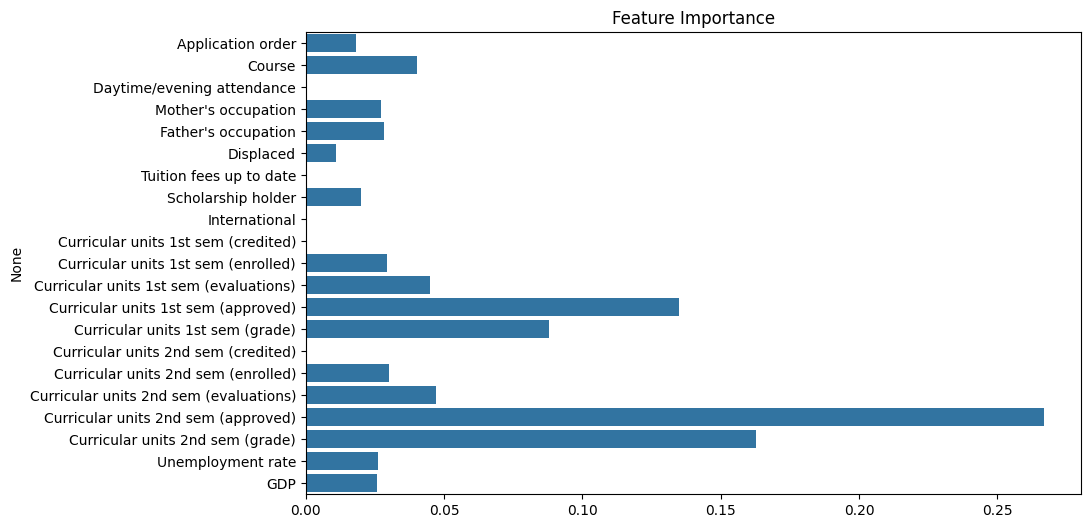

In [39]:
feature_importances = best_rf.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=X.columns)
plt.title("Feature Importance")
plt.show()

## 5- SVM

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.706 total time=   0.1s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.706 total time=   0.1s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.709 total time=   0.1s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.709 total time=   0.1s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.709 total time=   0.1s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.847 total time=   0.3s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.841 total time=   0.4s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.847 total time=   0.4s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.859 total time=   0.3s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.856 total time=   0.3s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.884 total time=   0.1s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

<Axes: >

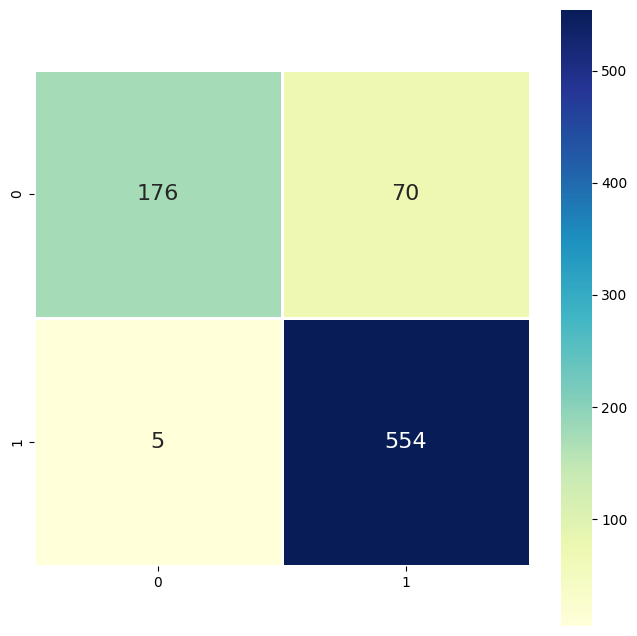

In [40]:
svcC = SVC()
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf', 'poly']}
grid_search = GridSearchCV(svcC, param_grid, cv=5, scoring='accuracy', refit=True, verbose=3)
grid_search.fit(X_train, y_train)

best_params_SVC = grid_search.best_params_
print("Best Parameters:", best_params_SVC)

best_svcC = SVC(gamma=best_params_SVC['gamma'], kernel=best_params_SVC['kernel'], C=best_params_SVC['C'])
best_svcC.fit(X_train, y_train)

y_pred = best_svcC.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

append_metrics(accuracy, precision, recall, f1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, fmt=".0f", cmap="YlGnBu", linewidth=1, square=True, annot=True, annot_kws={"fontsize": 16}, ax=ax)


#**XGBoost**

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [05:24:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'learning_rate': 0.2, 'max_depth': 20, 'n_estimators': 50, 'subsample': 0.9}
Accuracy: 0.90
Precision: 0.90
Recall: 0.90
F1-score: 0.90


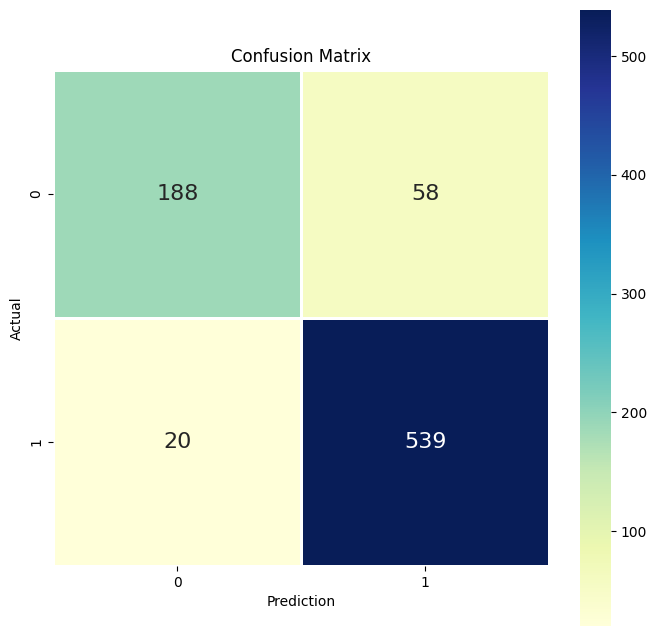

In [41]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Initialize the XGBoost classifier
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 20, 30],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

# Initialize GridSearchCV with the XGBoost classifier
grid_search = GridSearchCV(xgb_clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Train the best XGBoost model
best_xgb = xgb.XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    use_label_encoder=False,
    eval_metric='mlogloss'
)
best_xgb.fit(X_train, y_train)

# Predict on the test set
y_pred = best_xgb.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

# Append metrics to some storage if needed (assuming append_metrics is a custom function)
append_metrics(accuracy, precision, recall, f1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, fmt=".0f", cmap="YlGnBu", linewidth=1, square=True, annot=True, annot_kws={"fontsize": 16}, ax=ax)

ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 6-  Naive Bayes

Naive Bayes Classification:
Accuracy: 0.88
Precision: 0.89
Recall: 0.88
F1-score: 0.88


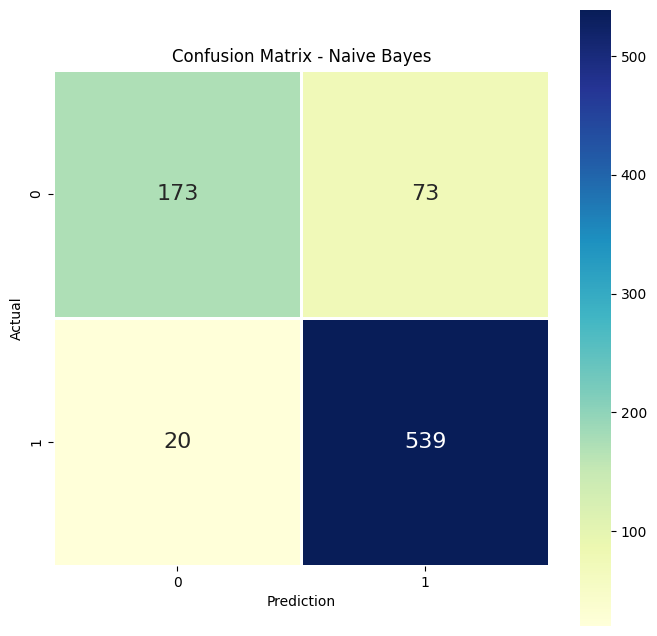

In [ ]:
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)


y_pred_naive_bayes = naive_bayes_model.predict(X_test)


accuracy_naive_bayes = accuracy_score(y_test, y_pred_naive_bayes)
precision_naive_bayes, recall_naive_bayes, f1_naive_bayes, _ = precision_recall_fscore_support(y_test, y_pred_naive_bayes, average='weighted')

print("Naive Bayes Classification:")
print(f"Accuracy: {accuracy_naive_bayes:.2f}")
print(f"Precision: {precision_naive_bayes:.2f}")
print(f"Recall: {recall_naive_bayes:.2f}")
print(f"F1-score: {f1_naive_bayes:.2f}")

append_metrics(accuracy_naive_bayes, precision_naive_bayes, recall_naive_bayes, f1_naive_bayes)

cm_naive_bayes = confusion_matrix(y_test, y_pred_naive_bayes)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm_naive_bayes, fmt=".0f", cmap="YlGnBu", linewidth=1, square=True, annot=True, annot_kws={"fontsize": 16}, ax=ax)
ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()



# 7. Model Evaluation and Comparison

In [ ]:
results_df = pd.DataFrame({
    'Algorithm': algorithms,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1': f1_scores
})

In [ ]:
results_df = results_df.sort_values(by='Accuracy', ascending=False)
results_df

,Algorithm,Accuracy,Precision,Recall,F1
3,Random Forest,0.908075,0.912132,0.908075,0.904363
4,SVM,0.906832,0.913660,0.906832,0.902301
1,Logistic Regression,0.900621,0.901714,0.900621,0.897460
5,Naive Bayes,0.884472,0.885503,0.884472,0.880113
0,K-Nearest Neighbors,0.880745,0.891486,0.880745,0.872636
2,Decision Tree,0.863354,0.870722,0.863354,0.854062


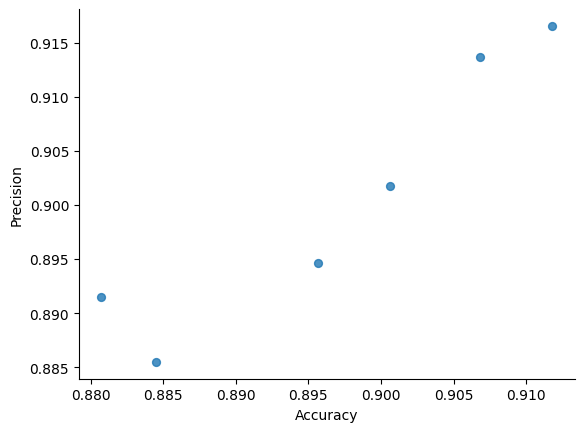

In [ ]:
# @title Accuracy vs Precision

from matplotlib import pyplot as plt
results_df.plot(kind='scatter', x='Accuracy', y='Precision', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

<ipython-input-59-07f287e46786>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(results_df, x='Accuracy', y='Algorithm', inner='stick', palette='Dark2')


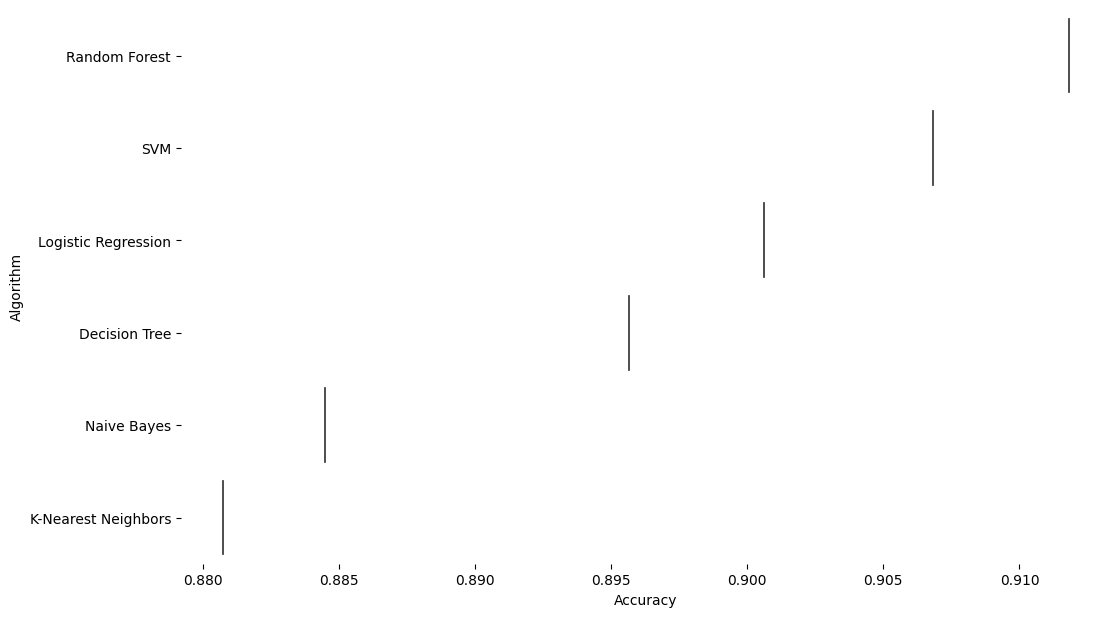

In [ ]:
# @title Algorithm vs Accuracy

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results_df['Algorithm'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results_df, x='Accuracy', y='Algorithm', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

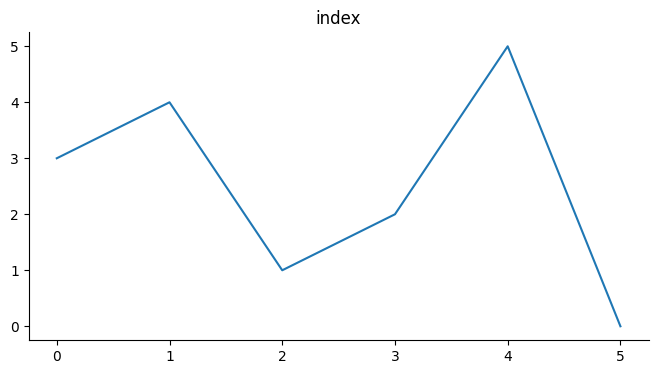

In [ ]:
from matplotlib import pyplot as plt
_df_9['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

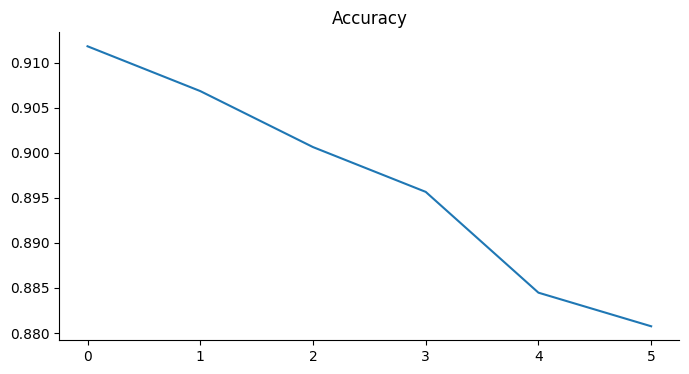

In [ ]:
from matplotlib import pyplot as plt
_df_10['Accuracy'].plot(kind='line', figsize=(8, 4), title='Accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

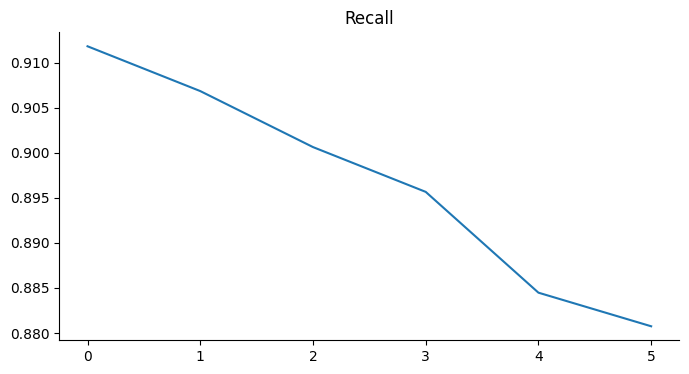

In [ ]:
from matplotlib import pyplot as plt
_df_12['Recall'].plot(kind='line', figsize=(8, 4), title='Recall')
plt.gca().spines[['top', 'right']].set_visible(False)

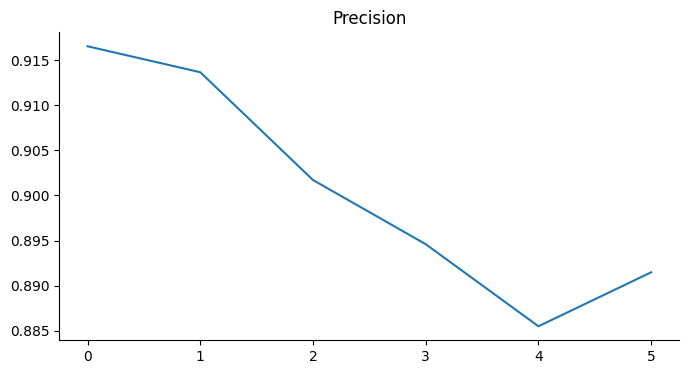

In [ ]:
from matplotlib import pyplot as plt
_df_11['Precision'].plot(kind='line', figsize=(8, 4), title='Precision')
plt.gca().spines[['top', 'right']].set_visible(False)

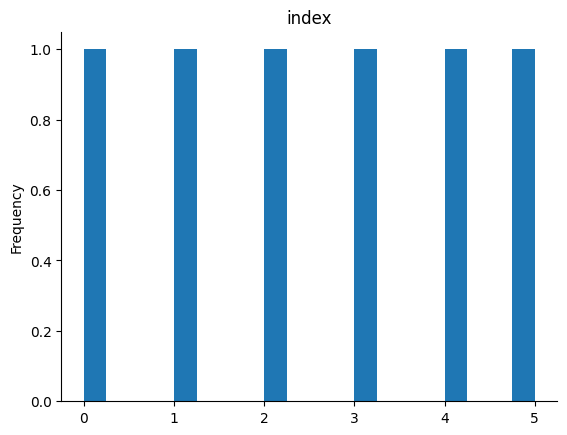

In [ ]:
from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

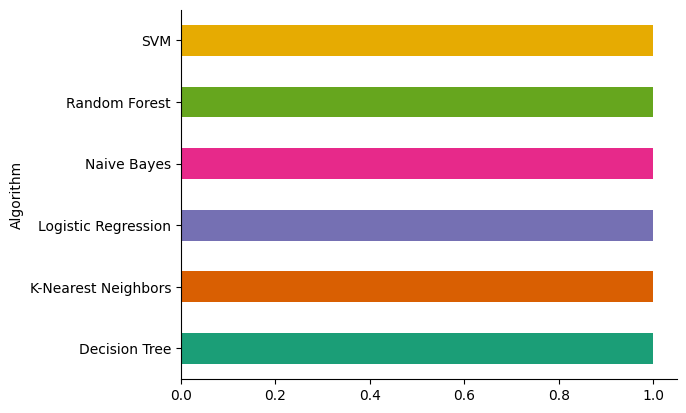

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('Algorithm').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)